# 09 — Où le machine learning gagne-t-il sa place ?

Le notebook 08 s'est conclu sur un verdict dérangeant : un test statistique à un
paramètre fait jeu égal avec un Random Forest de 100 arbres. Ce notebook attaque le
jalon 4 en posant la question frontalement, sur deux régimes où l'on s'attend à ce que
l'apprentissage apporte une valeur réelle :

1. **Bruit corrélé entre composantes** (mode commun) : la statistique « norme estimée »
   reste-t-elle suffisante quand le bruit a une structure ?
2. **Diagnostic multiclasse de la cause d'invalidité** : détecter ne suffit pas — un
   système embarqué doit *isoler* la cause pour choisir la récupération adaptée
   (logique FDIR : *Fault Detection, Isolation and Recovery* des satellites).

**Méthode de ce notebook** : les expériences ont été exécutées AVANT d'écrire les
interprétations. Les conclusions suivent les chiffres — y compris quand ils
contredisent l'intuition initiale. C'est arrivé, et c'est documenté.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from qsv.data_generation import create_dataset, create_multiclass_dataset
from qsv.features import add_correlated_noise, compute_features, sigma_from_shots

RANDOM_STATE = 42
%matplotlib inline
print("Environnement prêt")


Environnement prêt


## 1. Bruit équicorrélé : le mode commun

### Le modèle

Dans un instrument réel, une partie du bruit est **partagée par toutes les voies de
mesure** : vibration du porteur sur un interféromètre atomique, fluctuation du laser de
lecture, dérive thermique de la chaîne d'acquisition. On modélise chaque partie
(réelle/imaginaire) de chaque composante par :

$$\varepsilon_i = \sigma\left(\sqrt{\rho}\, z + \sqrt{1-\rho}\, w_i\right),
\qquad z \sim \mathcal{N}(0,1) \text{ commun}, \quad w_i \sim \mathcal{N}(0,1) \text{ i.i.d.}$$

**Lecture** : « epsilon-i égale sigma fois racine de rho fois z, plus racine de un moins
rho fois w-i ». Le paramètre ρ est la corrélation entre composantes ; la variance par
composante reste σ² quel que soit ρ — **seule la structure du bruit change**, pas son
intensité. C'est le contrôle expérimental propre : toute différence de performance
viendra de la structure, pas d'un bruit plus fort.

### L'hypothèse à tester

Le bruit sur ‖ψ̂‖² devient hétéroscédastique : sa variance dépend de l'état via le
couplage $2z\sum_i c_i$ entre mode commun et somme des amplitudes. Un seuil global
ignore cette structure ; un modèle disposant des 8 coordonnées pourrait l'exploiter.
**Hypothèse : le Random Forest bat le test à seuil quand ρ croît.** Vérifions.

rho=0.0 | test à seuil : 0.9164 | Random Forest : 0.9152


rho=0.5 | test à seuil : 0.9156 | Random Forest : 0.9116


rho=0.9 | test à seuil : 0.9104 | Random Forest : 0.9124


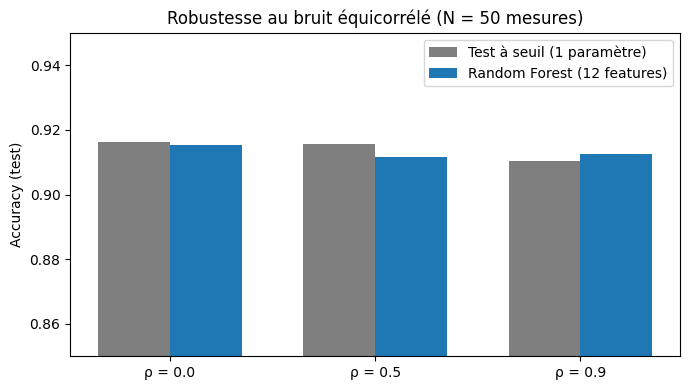

In [2]:
DIM, N = 4, 50
sigma = sigma_from_shots(N)
df = create_dataset(5000, 5000, dim=DIM, seed=RANDOM_STATE)

results_a = {}
for rho in (0.0, 0.5, 0.9):
    d = add_correlated_noise(df, n_shots=N, rho=rho, seed=RANDOM_STATE)
    y = d["is_valid"]
    stat = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("t_stat")
    X = pd.concat(
        [d[[c for c in d.columns if c.startswith("c")]],
         compute_features(d, kind="all")], axis=1)

    X_tr, X_te, s_tr, s_te, y_tr, y_te = train_test_split(
        X, stat, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    stump.fit(s_tr, y_tr)
    rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    results_a[rho] = {
        "seuil": accuracy_score(y_te, stump.predict(s_te)),
        "rf": accuracy_score(y_te, rf.predict(X_te)),
    }
    print(f"rho={rho:.1f} | test à seuil : {results_a[rho]['seuil']:.4f} | "
          f"Random Forest : {results_a[rho]['rf']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
rhos = list(results_a)
w = 0.35
ax.bar([r - w/2 for r in range(3)], [results_a[r]["seuil"] for r in rhos],
       width=w, label="Test à seuil (1 paramètre)", color="tab:gray")
ax.bar([r + w/2 for r in range(3)], [results_a[r]["rf"] for r in rhos],
       width=w, label="Random Forest (12 features)", color="tab:blue")
ax.set_xticks(range(3)); ax.set_xticklabels([f"ρ = {r}" for r in rhos])
ax.set_ylim(0.85, 0.95); ax.set_ylabel("Accuracy (test)")
ax.set_title(f"Robustesse au bruit équicorrélé (N = {N} mesures)")
ax.legend(); plt.tight_layout(); plt.show()

### Verdict : hypothèse réfutée — et c'est le résultat le plus utile du notebook

Le test à seuil **résiste au mode commun** (‑0,6 point entre ρ = 0 et ρ = 0,9) et le
Random Forest n'en tire aucun avantage exploitable. Pourquoi l'intuition était fausse :
le couplage mode commun ↔ signal passe par $z\sum_i c_i$, or pour des états aléatoires
les amplitudes sont centrées — la somme $\sum_i c_i$ reste petite et le mode commun
**se moyenne presque entièrement dans la statistique de norme**, qui agrège 2d = 8
composantes. La somme est un filtre passe-bas naturel du mode commun.

**Valeur ingénierie de ce résultat négatif** : pour ce régime de bruit, un validateur
embarqué n'a *pas besoin* de modèle appris — un seuil calibré suffit, y compris sous
corrélation forte. C'est une garantie de robustesse qu'aucune accuracy de ML ne
remplace : moins de complexité à qualifier, moins de surface de défaillance. En
ingénierie spatiale, le composant le plus fiable est celui qu'on n'embarque pas.

## 2. Diagnostic multiclasse : isoler la cause d'invalidité

Détecter qu'un état est invalide ne dit pas *pourquoi*. Le générateur produit quatre
mécanismes d'invalidité distincts — `scaling` (mauvaise normalisation globale),
`noise` (perturbation additive), `direct` (génération non contrainte), `extreme`
(défaillances franches). Contrairement à la validité, **la cause n'est pas une fonction
déterministe des amplitudes** : les distributions se chevauchent. C'est structurellement
un problème d'inférence statistique.

Analogie FDIR : un satellite qui détecte une dérive de capteur doit décider s'il s'agit
d'un biais de calibration (recalibrer), d'un bruit anormal (filtrer/attendre) ou d'une
défaillance franche (basculer sur la redondance). Chaque diagnostic déclenche une
récupération différente — se tromper de cause coûte plus cher que détecter en retard.

{'valid': 4000, 'scaling': 1000, 'extreme': 1000, 'noise': 1000, 'direct': 1000}



Random Forest (12 features)   : 0.8990
Arbre sur la norme seule (1D) : 0.8950


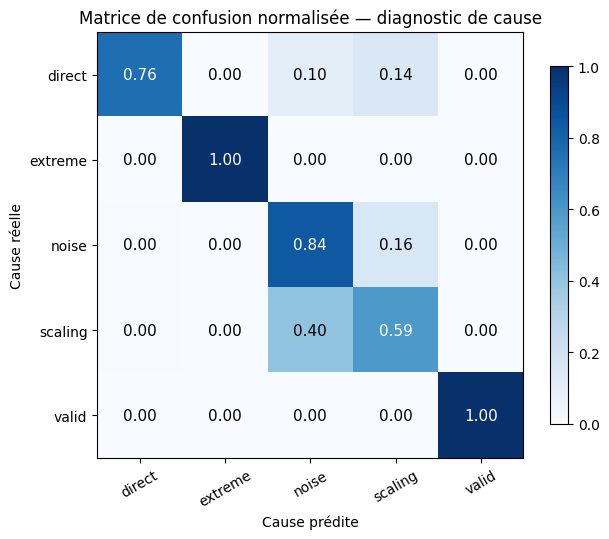

In [3]:
mc = create_multiclass_dataset(n_valid=4000, n_per_cause=1000, dim=DIM, seed=RANDOM_STATE)
print(mc["cause"].value_counts().to_dict())

X = pd.concat(
    [mc[[c for c in mc.columns if c.startswith("c") and c != "cause"]],
     compute_features(mc, kind="all")], axis=1)
y = mc["cause"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)
acc_rf = accuracy_score(y_te, rf.predict(X_te))

tree_norm = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_norm.fit(X_tr[["norm_squared"]], y_tr)
acc_norm = accuracy_score(y_te, tree_norm.predict(X_te[["norm_squared"]]))

print(f"\nRandom Forest (12 features)   : {acc_rf:.4f}")
print(f"Arbre sur la norme seule (1D) : {acc_norm:.4f}")

labels = sorted(y.unique())
cm = confusion_matrix(y_te, rf.predict(X_te), labels=labels, normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black", fontsize=11)
ax.set_xlabel("Cause prédite"); ax.set_ylabel("Cause réelle")
ax.set_title("Matrice de confusion normalisée — diagnostic de cause")
plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

### Lecture de la matrice — et la limite de Bayes

Trois régimes bien distincts :

- **`valid` et `extreme` : diagnostic parfait (1.00).** Leurs signatures de norme ne
  chevauchent rien (‖ψ‖² = 1 exactement ; ‖ψ‖² énorme ou quasi nulle).
- **`direct` et `noise` : bons (0.76–0.84)**, erreurs résiduelles vers les causes de
  norme voisine.
- **`scaling` : 0.59, confondu à 40 % avec `noise`.** Ce n'est PAS une faiblesse du
  modèle — c'est une **limite de Bayes**, démontrable par un argument d'isotropie :

Un état `scaling` est k·|ψ_valide⟩ : sa *direction* dans l'espace de Hilbert est
exactement celle d'un état valide — uniforme sur la sphère. Un état `noise` est
|ψ_valide⟩ + ε avec ε isotrope : sa direction renormalisée est... également uniforme
sur la sphère. **Les directions ne portent aucune information discriminante entre ces
deux causes.** Il ne reste que la norme, et les densités de ‖ψ‖² des deux mécanismes se
chevauchent sur [0.9, ~1.7]. Dans la zone de chevauchement, aucun classifieur — si
profond soit-il — ne peut faire mieux que le rapport des densités.

C'est confirmé par la comparaison : le Random Forest à 12 features ne bat l'arbre sur
la **norme seule** que de quelques dixièmes de point. L'information est dans la norme ;
le reste est du bruit d'isotropie.

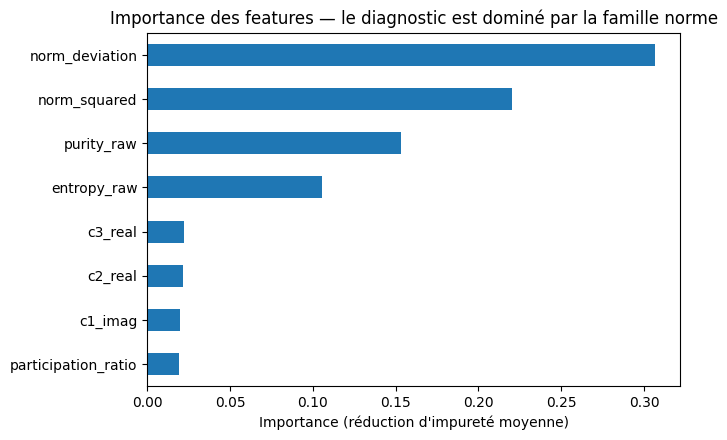

entropy_raw       0.105
purity_raw        0.153
norm_squared      0.220
norm_deviation    0.306


In [4]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.tail(8).plot.barh(ax=ax, color="tab:blue")
ax.set_title("Importance des features — le diagnostic est dominé par la famille norme")
ax.set_xlabel("Importance (réduction d'impureté moyenne)")
plt.tight_layout(); plt.show()
print(imp.tail(4).round(3).to_string())

## Conclusion du jalon 4a

1. **Résultat négatif assumé** : le test à seuil est robuste au bruit équicorrélé — le
   mode commun se moyenne dans la statistique de norme. Pour ce régime, l'ingénieur
   n'embarque pas de modèle : un seuil calibré est plus simple, plus sûr, qualifiable.
2. **Le diagnostic de cause est le premier vrai métier du ML dans ce projet** (90 %
   là où un seuil binaire ne dit rien de la cause), mais sa performance reste dominée
   par la norme, et la confusion scaling↔noise est une **limite de Bayes** prouvée par
   isotropie — pas un défaut d'algorithme.
3. **La leçon transverse du projet se confirme une troisième fois** : comprendre la
   structure du problème (suffisance de la norme, isotropie des directions) prédit et
   explique ce que les modèles peuvent — et ne peuvent pas — apprendre.

### Ce qu'il faudra pour que le ML gagne vraiment (jalon 4b)

Le ML l'emportera quand une structure **anisotrope ou temporelle** échappera à toute
statistique scalaire : dérive de calibration lentement variable (le seuil fixe devient
sous-optimal, un modèle avec contexte temporel compense), bruit coloré par composante
(voies d'acquisition inégales), causes corrélées à la direction (préparation défaillante
d'états cibles *connus* — là, la référence directionnelle existe et l'isotropie est
brisée). Chaque extension devra être physiquement motivée — c'est inscrit dans la
ROADMAP.

*Modules : `src/features.py` (`add_correlated_noise`), `src/data_generation.py`
(`create_multiclass_dataset`, stratégie `extreme`). Tests : `tests/test_features.py`,
`tests/test_data_generation.py`.*